# Lab 3: Bayesian Analysis & Continuous Distributions

**Phân tích dữ liệu Bayesian - IUH**

Một chiếc hộp kín đặt trước mặt ta. Bên trong có 10 viên bi, nhưng ta chưa biết có bao nhiêu viên đỏ. Mỗi lần bốc ra một viên là một lần thế giới hé lộ thêm một chút, và niềm tin của ta buộc phải thay đổi theo. Từ tình huống rất cụ thể ấy, Lab 3 mở dần ra những câu hỏi rộng hơn: nếu điều chưa biết không còn là một số đếm rời rạc mà là tuổi thọ của linh kiện, chiều cao của sinh viên, hay một đại lượng liên tục nói chung, thì ta phải mô tả bất định bằng cách nào?

Điểm thú vị của lab này là mọi bài đều xoay quanh cùng một công việc: đọc dữ liệu trong đúng bối cảnh sinh ra nó. Có bài yêu cầu cập nhật niềm tin từng bước. Có bài yêu cầu chọn đúng phân phối để mô tả thời gian chờ. Có bài lại nhắc rằng trước khi tính bất cứ thứ gì, ta phải kiểm tra xem hàm đang xét có thật sự là một mật độ xác suất hợp lệ hay không.


In [1]:
# Các thư viện này đủ cho toàn bộ Lab 3: phân phối liên tục, tích phân số và trực quan hóa.
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.integrate import quad
from scipy.optimize import brentq

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(2024)
plt.rcParams["figure.figsize"] = (10, 5)


## 1. Từ chiếc hộp kín đến những đại lượng liên tục

Bài đầu tiên của lab là một bài Bayes rất “thật tay”: ta không biết cấu trúc bên trong chiếc hộp, và chỉ có thể học dần từ chuỗi quan sát khi bốc từng viên bi không hoàn lại. Ở đây, điều chưa biết là một trạng thái rời rạc của thế giới, còn dữ liệu đến theo thứ tự thời gian. Vì vậy, posterior không phải một thứ xuất hiện đột ngột ở cuối bài, mà là thứ dịch chuyển sau từng lần nhìn thấy đỏ hay xanh.

Nhưng rồi câu chuyện đổi nhịp. Sang các bài tiếp theo, điều chưa biết không còn là số bi đỏ nữa mà là những đại lượng liên tục như tuổi thọ hay chiều cao. Lúc này, ta không còn đếm các khả năng hữu hạn, mà phải làm quen với mật độ, hàm phân phối tích lũy, kỳ vọng và phương sai như những công cụ để mô tả một không gian khả năng liên tục hơn nhiều.


## 2. Khi xác suất không còn là bài toán đếm

Ở phần biến liên tục, một thay đổi rất quan trọng xảy ra: xác suất không còn gắn với từng giá trị riêng lẻ mà gắn với khoảng giá trị. Ta không hỏi “biến này bằng đúng bao nhiêu” theo kiểu đếm trường hợp nữa, mà hỏi nó rơi vào khoảng nào, kỳ vọng ở đâu, biến thiên mạnh đến mức nào, và giả định phân phối ta đang dùng có nói điều gì hợp lý về thế giới thật hay không.

Chính vì thế, Bài 2 đến Bài 4 không nên được đọc như những bài thay số vào công thức của Exponential hay Normal. Chúng là những bài tập về cách gắn một mô hình xác suất vào một hiện tượng thực tế. Nếu chọn phân phối mũ, ta đang nói điều gì về rủi ro hỏng theo thời gian? Nếu chọn phân phối chuẩn cho chiều cao, ta đang chấp nhận kiểu đối xứng và mức độ dao động nào trong quần thể?


### Một lưu ý quan trọng trước khi tính toán

Hai bài cuối của lab đóng vai trò như một lời nhắc rất mạnh: không phải hàm nào trông giống mật độ cũng thật sự là mật độ. Trước khi nói đến kỳ vọng, phương sai hay bất kỳ kết luận Bayesian nào, ta phải chắc rằng mô hình xác suất của mình hợp lệ trên đúng miền giá trị đang xét.

Vì vậy, nếu muốn giữ một sợi chỉ xuyên suốt cho toàn bộ lab, có thể giữ ba câu hỏi này trong đầu: điều chưa biết là gì, dữ liệu được sinh ra theo cơ chế nào, và mô hình xác suất mình đang dùng có thật sự hợp lệ để nối hai thứ đó với nhau hay không.


## 3. Bài 1 - Bi trong hộp: Bayesian update without replacement

### Đề bài nhắc lại

**Bài 1.** Trong một hộp có $10$ viên bi gồm hai màu đỏ và xanh nhưng chưa biết cụ thể số lượng. Gọi $A_k$ là biến cố hộp có đúng $k$ viên đỏ với $0\le k\le 10$. Người ta lấy ra lần lượt từng viên cho đến hết hộp.

- 1) Tìm xác suất hậu nghiệm của các biến cố $A_k$ sau khi lần đầu tiên bốc được bi đỏ.
- 2) Viết chương trình phân tích Bayes khi dãy bốc được ở 10 lần là $R,R,B,R,B,B,B,R,R,R$.

### Problem framing

Ta có một hộp gồm 10 viên bi, trong đó số viên đỏ $k$ là chưa biết. Đại lượng chưa biết ở đây không phải là “xác suất ra bi đỏ” theo nghĩa trừu tượng mà là chính số lượng bi đỏ trong hộp. Dữ liệu là chuỗi màu thu được khi bốc hết 10 viên không hoàn lại.

### Model specification

Ta đặt các giả thuyết $A_k$ với $k = 0, 1, \ldots, 10$, trong đó $A_k$ nghĩa là hộp có đúng $k$ viên đỏ. Trước khi quan sát gì, ta dùng prior đều:

$$
P(A_k) = \frac{1}{11}.
$$

Sau một quan sát, posterior được cập nhật bằng Bayes. Vì bốc không hoàn lại, likelihood ở mỗi bước phụ thuộc vào những gì đã thấy trước đó. Chẳng hạn, nếu đã thấy $r$ viên đỏ và $b$ viên xanh, thì dưới giả thuyết $A_k$:

$$
P(\text{red next} \mid A_k, r, b) = \frac{k-r}{10-r-b}, \qquad
P(\text{blue next} \mid A_k, r, b) = \frac{10-k-b}{10-r-b}.
$$

### Prior choice and justification

Prior đều là lựa chọn hợp lý khi đề không cho biết hộp thiên về đỏ hay xanh. Đây là prior “trung lập” theo nghĩa mọi giá trị $k=0,1,\ldots,10$ được đối xử như nhau trước khi nhìn dữ liệu.

Tuy nhiên, trong nhiều bối cảnh thực tế ta có thể có niềm tin mềm rằng chiếc hộp được chuẩn bị tương đối cân bằng, nghĩa là số bi đỏ và số bi xanh khó lệch quá xa nhau. Khi đó một prior tập trung quanh $k=5$ là hợp lý hơn. Một cách cụ thể để mô tả niềm tin này là dùng phân phối Binomial$(10,0.5)$ trên $k$: nó đặt khối lượng lớn nhất ở $k=5$, giảm dần khi đi về hai đầu $k=0$ hay $k=10$, nhưng vẫn không loại bỏ hoàn toàn các trường hợp cực đoan.

Điểm cần nhấn mạnh là prior quanh $k=5$ không nói rằng ta “biết” hộp cân bằng. Nó chỉ nói rằng trước khi quan sát, ta xem các hộp gần cân bằng là đáng tin hơn các hộp cực đoan. Vì vậy, ở giai đoạn đầu của chuỗi dữ liệu, prior này sẽ kéo posterior về vùng trung tâm mạnh hơn prior đều. Nhưng nếu quan sát đủ nhiều, dữ liệu sẽ dần lấn át prior: posterior không tự động tăng niềm tin vào trạng thái cân bằng, mà ngày càng tập trung vào giá trị $k$ mà dữ liệu thực sự ủng hộ. Trong ví dụ này, vì chuỗi quan sát chứa 6 viên đỏ và 4 viên xanh, cả hai cách khởi đầu cuối cùng đều hội tụ về $k=6$, chứ không phải về $k=5$.

### Ý nghĩa của bài tập

Bài này rất quan trọng vì nó cho thấy Bayes có thể áp dụng ngay cả khi tham số ẩn không phải là một xác suất liên tục mà là một trạng thái rời rạc cụ thể của thế giới, ở đây là số bi đỏ trong hộp. Mỗi lượt bốc không hoàn lại vừa cung cấp thêm dữ liệu, vừa thay đổi likelihood của lượt kế tiếp.

Ý nghĩa sâu hơn là giúp người học nhìn rõ posterior như một đối tượng sống động: nó không chỉ xuất hiện ở cuối bài, mà được cập nhật dần sau từng quan sát. Đây là một trong những ví dụ tốt nhất để xây trực giác về sequential updating.


### Công thức cốt lõi và cách đọc

Gọi $$A_k$$ là giả thuyết trong hộp có đúng $$k$$ viên đỏ, với $$k=0,1,\ldots,10$$. Nếu prior là $$\pi(k)=P(A_k)$$ và lần bốc đầu ra đỏ, thì posterior được cập nhật bởi:

$$
P(A_k\mid R_1) \propto P(R_1\mid A_k)\pi(k)=\frac{k}{10}\pi(k).
$$

Sau khi chuẩn hóa, ta có:

$$
P(A_k\mid R_1)=\frac{\frac{k}{10}\pi(k)}{\sum_{j=0}^{10}\frac{j}{10}\pi(j)}.
$$

Nếu đã quan sát $$r$$ viên đỏ và $$b$$ viên xanh theo cơ chế không hoàn lại, likelihood dưới giả thuyết $$A_k$$ có thể viết bằng tích tuần tự hoặc bằng falling factorial:

$$
P(\text{data}\mid A_k)=\frac{(k)_r (10-k)_b}{(10)_{r+b}}.
$$

Bài này cho thấy Bayes không chỉ suy luận về xác suất đỏ, mà có thể suy luận trực tiếp về cấu trúc ẩn của thế giới, ở đây là số bi đỏ trong hộp.


Posterior sau lần đầu bốc được bi đỏ với prior đều:
  P(A_1 | red, uniform prior) = 0.0182
  P(A_2 | red, uniform prior) = 0.0364
  P(A_3 | red, uniform prior) = 0.0545
  P(A_4 | red, uniform prior) = 0.0727
  P(A_5 | red, uniform prior) = 0.0909
  P(A_6 | red, uniform prior) = 0.1091
  P(A_7 | red, uniform prior) = 0.1273
  P(A_8 | red, uniform prior) = 0.1455
  P(A_9 | red, uniform prior) = 0.1636
  P(A_10 | red, uniform prior) = 0.1818

Posterior sau lần đầu bốc được bi đỏ với prior tập trung quanh k=5:
  P(A_1 | red, centered prior) = 0.0020
  P(A_2 | red, centered prior) = 0.0176
  P(A_3 | red, centered prior) = 0.0703
  P(A_4 | red, centered prior) = 0.1641
  P(A_5 | red, centered prior) = 0.2461
  P(A_6 | red, centered prior) = 0.2461
  P(A_7 | red, centered prior) = 0.1641
  P(A_8 | red, centered prior) = 0.0703
  P(A_9 | red, centered prior) = 0.0176
  P(A_10 | red, centered prior) = 0.0020

Posterior cuối cùng sau khi bốc hết hộp (prior đều):
  P(A_6 | full sequence, uniform 

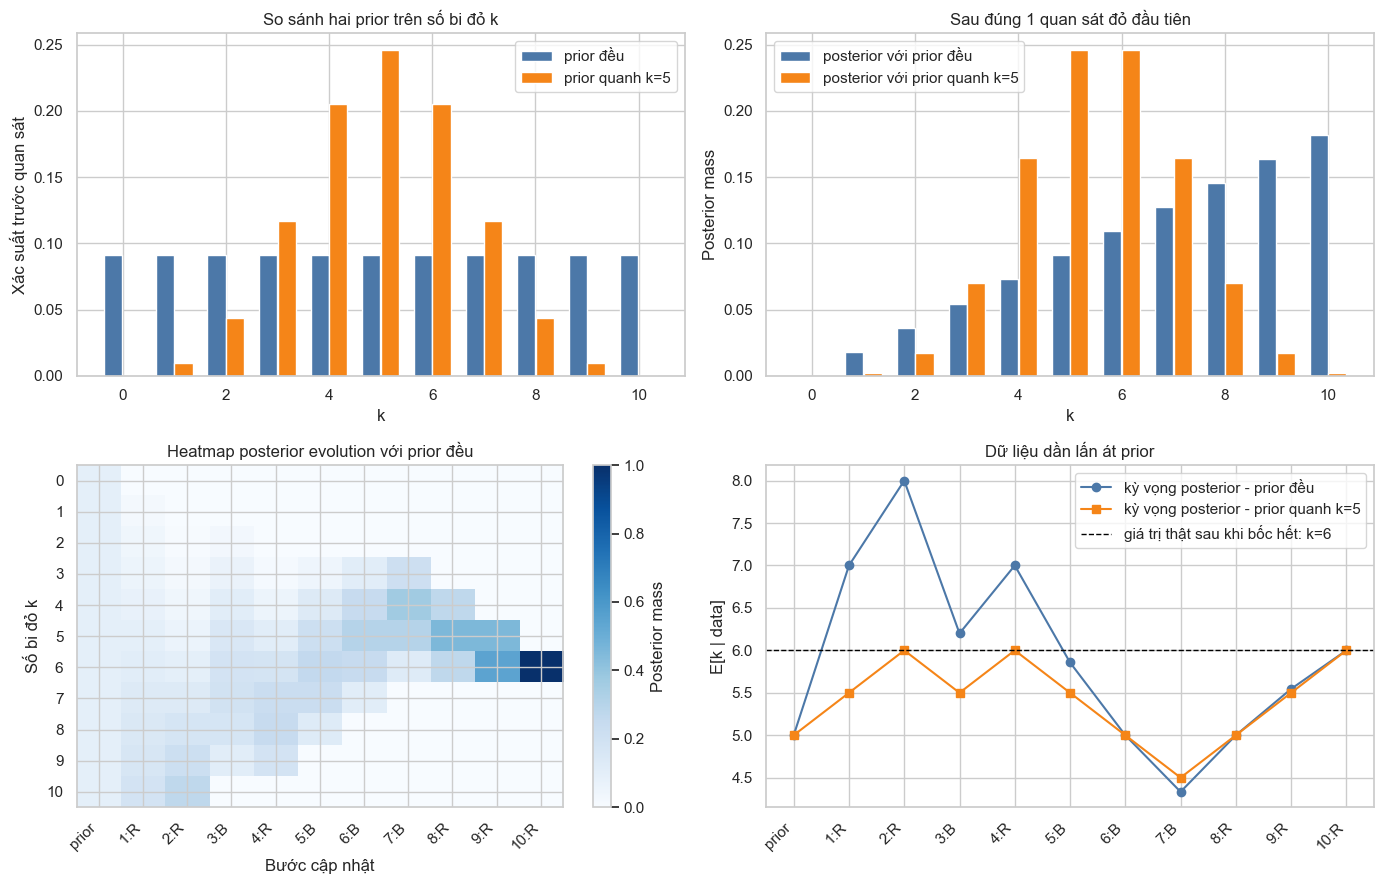

In [2]:
# Bài 1 minh họa Bayesian update trên không gian giả thuyết hữu hạn về số bi đỏ trong hộp.
k_values = np.arange(11)
# Prior đều: mọi cấu hình số bi đỏ đều được đối xử như nhau trước dữ liệu.
prior_uniform = np.ones_like(k_values, dtype=float) / len(k_values)
# Prior tập trung quanh k=5: mã hóa niềm tin mềm rằng hộp thường khá cân bằng.
prior_centered = stats.binom.pmf(k_values, 10, 0.5)
prior_centered = prior_centered / prior_centered.sum()
observations = ["R", "R", "B", "R", "B", "B", "B", "R", "R", "R"]

def normalize(probabilities):
    probabilities = np.asarray(probabilities, dtype=float)
    total = probabilities.sum()
    return probabilities / total if total > 0 else probabilities

def sequential_update(observations, prior):
    posterior = prior.copy()
    red_seen = 0
    blue_seen = 0
    # history[t] lưu posterior sau t bước, giúp ta nhìn được toàn bộ quá trình cập nhật.
    history = [posterior.copy()]

    for obs in observations:
        remaining = 10 - red_seen - blue_seen
        if obs == "R":
            # Với bốc không hoàn lại, likelihood phải trừ đi số bi đỏ đã thấy trước đó.
            likelihood = np.maximum(k_values - red_seen, 0) / remaining
            red_seen += 1
        else:
            # Tương tự, số bi xanh khả dĩ cũng giảm dần theo dữ liệu đã quan sát.
            likelihood = np.maximum((10 - k_values) - blue_seen, 0) / remaining
            blue_seen += 1
        posterior = normalize(posterior * likelihood)
        history.append(posterior.copy())
    return np.array(history)

# So sánh ảnh hưởng của prior ngay sau đúng một quan sát đầu tiên.
posterior_after_first_red_uniform = normalize(prior_uniform * (k_values / 10))
posterior_after_first_red_centered = normalize(prior_centered * (k_values / 10))
history_uniform = sequential_update(observations, prior_uniform)
history_centered = sequential_update(observations, prior_centered)
final_posterior_uniform = history_uniform[-1]
final_posterior_centered = history_centered[-1]

print("Posterior sau lần đầu bốc được bi đỏ với prior đều:")
for k, prob in zip(k_values, posterior_after_first_red_uniform):
    if prob > 0:
        print(f"  P(A_{k} | red, uniform prior) = {prob:.4f}")

print("\nPosterior sau lần đầu bốc được bi đỏ với prior tập trung quanh k=5:")
for k, prob in zip(k_values, posterior_after_first_red_centered):
    if prob > 0.001:
        print(f"  P(A_{k} | red, centered prior) = {prob:.4f}")

print("\nPosterior cuối cùng sau khi bốc hết hộp (prior đều):")
for k, prob in zip(k_values, final_posterior_uniform):
    if prob > 1e-12:
        print(f"  P(A_{k} | full sequence, uniform prior) = {prob:.4f}")

print("\nPosterior cuối cùng sau khi bốc hết hộp (prior tập trung quanh k=5):")
for k, prob in zip(k_values, final_posterior_centered):
    if prob > 1e-12:
        print(f"  P(A_{k} | full sequence, centered prior) = {prob:.4f}")

# Kỳ vọng posterior là một cách gọn để theo dõi hai quá trình hội tụ có nhanh như nhau không.
posterior_mean_uniform = history_uniform @ k_values
posterior_mean_centered = history_centered @ k_values
steps = np.arange(len(observations) + 1)
step_labels = ["prior"] + [f"{i}:{obs}" for i, obs in enumerate(observations, start=1)]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
# Bố cục 4 ô: prior, posterior sau 1 bước, heatmap diễn tiến, và đường hội tụ của E[k | data].

axes[0, 0].bar(k_values - 0.18, prior_uniform, width=0.35, label="prior đều", color="#4C78A8")
axes[0, 0].bar(k_values + 0.18, prior_centered, width=0.35, label="prior quanh k=5", color="#F58518")
axes[0, 0].set_title("So sánh hai prior trên số bi đỏ k")
axes[0, 0].set_xlabel("k")
# Trục x: số bi đỏ có thể có trong hộp, tức các khả năng k = 0,1,...,10.
axes[0, 0].set_ylabel("Xác suất trước quan sát")
# Trục y: xác suất prior của từng khả năng đó, tức P(A_k).
axes[0, 0].legend()

axes[0, 1].bar(k_values - 0.18, posterior_after_first_red_uniform, width=0.35, label="posterior với prior đều", color="#4C78A8")
axes[0, 1].bar(k_values + 0.18, posterior_after_first_red_centered, width=0.35, label="posterior với prior quanh k=5", color="#F58518")
axes[0, 1].set_title("Sau đúng 1 quan sát đỏ đầu tiên")
axes[0, 1].set_xlabel("k")
# Trục x: vẫn là các khả năng về số bi đỏ có thể có trong hộp.
axes[0, 1].set_ylabel("Posterior mass")
# Trục y: xác suất hậu nghiệm của từng khả năng đó sau khi thấy 1 viên đỏ, tức P(A_k | red).
axes[0, 1].legend()

# Heatmap này giữ prior đều để người đọc tập trung vào cơ chế cập nhật tuần tự.
image = axes[1, 0].imshow(history_uniform.T, aspect="auto", cmap="Blues")
axes[1, 0].set_yticks(np.arange(len(k_values)))
axes[1, 0].set_yticklabels(k_values)
axes[1, 0].set_xticks(steps)
axes[1, 0].set_xticklabels(step_labels, rotation=45, ha="right")
axes[1, 0].set_xlabel("Bước cập nhật")
# Trục x: prior, rồi từng bước quan sát 1:R, 2:R, 3:B, ... trong chuỗi dữ liệu.
axes[1, 0].set_ylabel("Số bi đỏ k")
# Trục y: các khả năng k = 0,1,...,10 về số bi đỏ có thể có trong hộp.
axes[1, 0].set_title("Heatmap posterior evolution với prior đều")
fig.colorbar(image, ax=axes[1, 0], label="Posterior mass")
# Thanh màu: độ lớn của posterior P(A_k | dữ liệu đến bước t); màu đậm hơn nghĩa là giả thuyết đó được ủng hộ hơn.

# Hai đường khác nhau lúc đầu nhưng sẽ cùng đi về giá trị mà dữ liệu thật sự ủng hộ.
axes[1, 1].plot(steps, posterior_mean_uniform, marker="o", label="kỳ vọng posterior - prior đều", color="#4C78A8")
axes[1, 1].plot(steps, posterior_mean_centered, marker="s", label="kỳ vọng posterior - prior quanh k=5", color="#F58518")
axes[1, 1].axhline(6, color="black", linestyle="--", linewidth=1, label="giá trị thật sau khi bốc hết: k=6")
axes[1, 1].set_xticks(steps)
axes[1, 1].set_xticklabels(step_labels, rotation=45, ha="right")
axes[1, 1].set_ylabel("E[k | data]")
# Trục y: kỳ vọng hậu nghiệm của số bi đỏ sau mỗi bước; đây là tóm tắt một con số cho toàn bộ posterior.
axes[1, 1].set_title("Dữ liệu dần lấn át prior")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


### Posterior inference and interpretation

Hình đầu tiên nên được đọc theo từng lớp. Ở ô trên bên trái, prior đều và prior tập trung quanh $k=5$ khác nhau rõ rệt: prior đều cho mọi cấu hình cùng trọng số, còn prior Binomial$(10,0.5)$ xem các cấu hình cân bằng là đáng tin hơn. Ở ô trên bên phải, chỉ sau đúng một quan sát đỏ đầu tiên, cả hai posterior đều dịch sang bên phải, nhưng posterior đi từ prior quanh $k=5$ vẫn còn giữ nhiều khối lượng ở vùng trung tâm hơn. Nói cách khác, một mẩu dữ liệu chưa đủ để xóa ảnh hưởng của prior.

Ô dưới bên trái cho thấy với prior đều, posterior mass dần dồn vào $k=6$ khi chuỗi quan sát dài ra. Ô dưới bên phải làm điều đó rõ hơn bằng kỳ vọng posterior: hai đường khởi đầu khác nhau nhưng cùng hội tụ về 6 khi dữ liệu đầy đủ được nhìn thấy. Đây chính là thông điệp sư phạm quan trọng của bài: prior ảnh hưởng mạnh ở giai đoạn đầu, còn khi dữ liệu tích lũy đủ nhiều thì posterior chủ yếu đi theo tín hiệu mà dữ liệu mang lại.

Sau khi quan sát trọn vẹn 10 lượt, posterior sụp hoàn toàn vào $k=6$ với cả hai prior vì dữ liệu đã cho ta biết chính xác có 6 viên đỏ và 4 viên xanh trong hộp.

### Model criticism and reflection

Điểm đáng chú ý là ở bài này thứ tự các màu không cung cấp thêm thông tin về tổng số bi đỏ sau khi đã bốc hết hộp; thứ quyết định posterior cuối cùng chỉ là tổng số đỏ và xanh. Tuy nhiên, nếu ta chỉ quan sát vài lượt đầu thì cập nhật tuần tự là rất quan trọng, và cũng chính ở giai đoạn đó lựa chọn prior bắt đầu tạo khác biệt.

Prior tập trung quanh $k=5$ không phải là “đúng hơn” prior đều trong mọi tình huống. Nó chỉ đúng hơn khi ta có lý do bối cảnh để tin rằng hộp được chuẩn bị khá cân bằng. Nếu hộp đến từ một quy trình có thể tạo ra cấu hình cực đoan, prior đều lại là lựa chọn an toàn hơn. Đây cũng là nơi nên nhấn mạnh rằng “xác suất” ở đây là bất định về trạng thái của hộp, không phải ngẫu nhiên nội tại của $k$.


## 4. Bài 2 - Exponential distribution và tuổi thọ linh kiện

### Problem framing

Tuổi thọ của mạch điện tử được mô hình bằng phân phối mũ với kỳ vọng 6.25 năm. Câu hỏi thực tế là xác suất linh kiện hỏng trước khi hết bảo hành 5 năm. Đại lượng chưa biết ở đây là thời điểm hỏng hóc của một linh kiện ngẫu nhiên trong quần thể.

### Model specification

Nếu $X \sim \text{Exponential}(\lambda)$, thì:

$$
E[X] = \frac{1}{\lambda} = 6.25 \quad \Rightarrow \quad \lambda = 0.16.
$$

Xác suất phải thay trong thời gian bảo hành là:

$$
P(X \le 5) = 1 - e^{-\lambda 5}.
$$

Mô hình này hợp lý khi xác suất hỏng trong một khoảng rất ngắn là gần như tỷ lệ với độ dài khoảng đó và không phụ thuộc vào tuổi linh kiện hiện tại. Đây chính là ý tưởng đứng sau hai khái niệm quan trọng: memoryless và hazard rate.

Tính **memoryless** của phân phối mũ nói rằng nếu linh kiện đã sống đến thời điểm $s$, thì phân phối của thời gian sống thêm không đổi:

$$
P(X > s+t \mid X > s) = P(X > t).
$$

Nói bằng lời, việc linh kiện đã chạy được một thời gian không làm thay đổi xác suất nó còn sống thêm bao lâu nữa. Mô hình này vì thế được gọi là “không nhớ quá khứ”.

**Hazard rate** là rủi ro hỏng tức thời tại thời điểm $t$, với điều kiện linh kiện vẫn còn hoạt động đến đúng thời điểm đó. Nếu gọi $f(t)$ là mật độ và $S(t)=P(X>t)$ là hàm sống sót, thì:

$$
h(t) = \frac{f(t)}{S(t)}.
$$

Với phân phối mũ, ta có $h(t)=\lambda$, tức hazard rate là hằng số. Chính việc hazard rate không đổi theo tuổi là lý do sâu hơn khiến phân phối mũ có tính memoryless.

### Ý nghĩa của bài tập

Bài này nhắc rằng việc chọn một phân phối không bao giờ là trung tính. Khi dùng phân phối mũ, ta đang chấp nhận một câu chuyện sinh dữ liệu rất cụ thể: rủi ro hỏng tức thời là không đổi theo thời gian và hệ thống không nhớ quá khứ.

Vì vậy, ý nghĩa của bài không chỉ nằm ở việc tính ra một xác suất bảo hành. Nó còn dạy sinh viên đọc mô hình như một tập giả định về thế giới, rồi tự hỏi giả định đó có hợp lý với bối cảnh kỹ thuật đang xét hay không.


### Đề bài nhắc lại

**Bài 2.** Tìm hiểu phân phối mũ qua các đoạn code tham khảo, rồi trả lời câu hỏi: nếu tuổi thọ của một mạch điện tử có phân phối mũ với kỳ vọng $6.25$ năm và thời gian bảo hành là $5$ năm, hãy tính xác suất mạch phải thay thế trong thời gian bảo hành.


### Công thức cốt lõi và cách đọc

Nếu tuổi thọ $$X$$ có kỳ vọng 6.25 năm, thì với tham số hóa theo rate ta có:

$$
E[X]=\frac{1}{\lambda}=6.25
\quad \Rightarrow \quad
\lambda=\frac{1}{6.25}=0.16.
$$

Mật độ và hàm phân phối tích lũy của phân phối mũ là:

$$
f(x)=\lambda e^{-\lambda x}, \qquad x\ge 0,
$$

$$
P(X\le t)=1-e^{-\lambda t}.
$$

Vì vậy xác suất phải thay thế linh kiện trong thời gian bảo hành 5 năm là:

$$
P(X\le 5)=1-e^{-0.16\cdot 5}.
$$

Ý nghĩa thực tế là ta đang chuyển một thông tin về tuổi thọ trung bình thành một xác suất ra quyết định liên quan đến chính sách bảo hành.


Rate lambda = 0.16 per year
P(X <= 5) = 0.5507


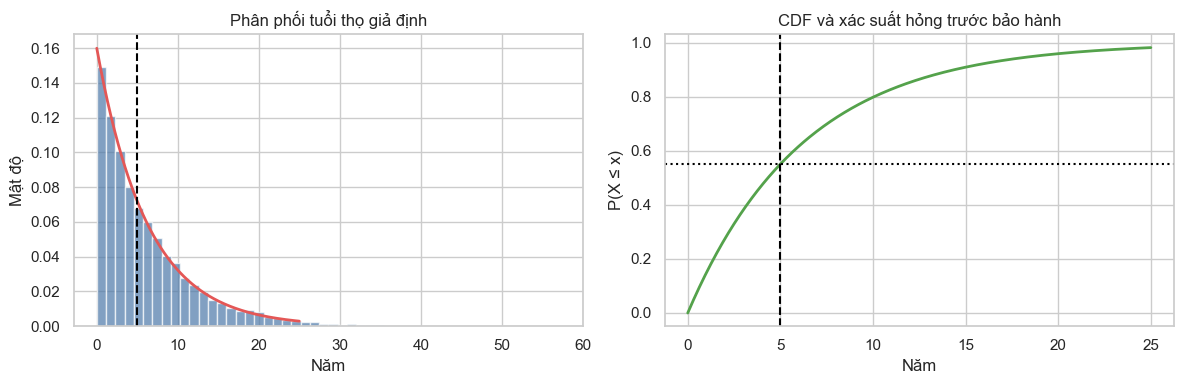

In [3]:
# Bài 2: mô hình hóa tuổi thọ bằng phân phối mũ rồi đọc xác suất bảo hành trên cả PDF lẫn CDF.
scale = 6.25
rate = 1 / scale
warranty_years = 5

x = np.linspace(0, 25, 400)
pdf = stats.expon.pdf(x, scale=scale)
cdf = stats.expon.cdf(x, scale=scale)
replacement_probability = stats.expon.cdf(warranty_years, scale=scale)

print(f"Rate lambda = {rate:.2f} per year")
print(f"P(X <= {warranty_years}) = {replacement_probability:.4f}")

sample = rng.exponential(scale=scale, size=10000)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(sample, bins=50, density=True, alpha=0.7, color="#4C78A8")
axes[0].plot(x, pdf, color="#E45756", linewidth=2)
axes[0].axvline(warranty_years, color="black", linestyle="--")
axes[0].set_title("Phân phối tuổi thọ giả định")
axes[0].set_xlabel("Năm")
axes[0].set_ylabel("Mật độ")

axes[1].plot(x, cdf, color="#54A24B", linewidth=2)
axes[1].axvline(warranty_years, color="black", linestyle="--")
axes[1].axhline(replacement_probability, color="black", linestyle=":")
axes[1].set_title("CDF và xác suất hỏng trước bảo hành")
axes[1].set_xlabel("Năm")
axes[1].set_ylabel("P(X ≤ x)")
plt.tight_layout()
plt.show()


### Interpretation and model criticism

Kết quả $P(X \le 5) \approx 0.5507$ cho thấy dưới mô hình mũ, xác suất linh kiện phải thay trong 5 năm bảo hành vào khoảng 55.1%. Đây là con số khá lớn: nếu mô hình đúng, hơn một nửa linh kiện sẽ hỏng trước khi hết hạn bảo hành.

Tuy nhiên, phân phối mũ ngầm giả định hazard rate là hằng số. Điều đó nghĩa là một linh kiện vừa mới lắp và một linh kiện đã chạy được 5 năm được xem là có cùng mức rủi ro hỏng tức thời trong khoảnh khắc kế tiếp, miễn là cả hai còn đang hoạt động. Đây là một giả định rất mạnh.

Giả định này thường hợp lý với lỗi ngẫu nhiên do sốc, lỗi sản xuất tiềm ẩn, hay các sự cố bất chợt không tích lũy theo thời gian. Nhưng nó kém hợp lý với linh kiện có hiện tượng “hao mòn” theo tuổi. Khi đó, hazard rate nên tăng dần theo thời gian thay vì giữ nguyên, và phân phối Weibull thường là một mô hình tốt hơn vì nó cho phép mô tả cả trường hợp hazard tăng, giảm, hoặc gần như hằng.


## 5. Bài 3 - Ôn tập phân phối chuẩn và sửa lỗi đề bài

### Problem framing

Đề bài yêu cầu tính $P(X \le 0 \mid X > -3)$ cho một biến chuẩn có $\mu = 4$ và $\sigma = -1$. Tham số độ lệch chuẩn không thể âm, nên đây là một lỗi ký hiệu trong đề gốc. Cách sửa tự nhiên nhất là hiểu rằng độ lệch chuẩn có độ lớn bằng 1, tức $\sigma = 1$.

### Model specification

Với cách sửa đó, ta cần tính:

$$
P(X \le 0 \mid X > -3) = \frac{P(-3 < X \le 0)}{P(X > -3)}.
$$

### Ý nghĩa của bài tập

Bài này là lời nhắc rất thực tế rằng trước khi làm bất kỳ phép suy luận nào, ta phải kiểm tra tham số hóa của mô hình có hợp lệ không. Một lỗi nhỏ như độ lệch chuẩn âm đủ để làm toàn bộ mô hình trở nên vô nghĩa.

Ở góc độ học tập, đây cũng là dịp để ôn lại cách đọc xác suất điều kiện trong bối cảnh liên tục. Ta không đếm phần tử của một tập hợp nữa, mà làm việc với xác suất trên các khoảng và dùng CDF như công cụ trung gian.


### Đề bài nhắc lại

**Bài 3.** Xét biến ngẫu nhiên chuẩn với tham số ghi trong đề là $\mu=4,\ \sigma=-1$. Hãy tính xác suất có điều kiện
$$P(X\le 0\mid X>-3).$$
Phần solution cần đồng thời chỉ ra và sửa lỗi mô hình vì độ lệch chuẩn không thể âm.


### Công thức cốt lõi và cách đọc

Với phân phối chuẩn, xác suất có điều kiện được viết lại bằng tỉ số của hai xác suất trên các khoảng:

$$
P(X\le 0\mid X>-3)=\frac{P(-3<X\le 0)}{P(X>-3)}.
$$

Nếu sửa lỗi đề và dùng $$\sigma=1$$, công thức theo hàm phân phối chuẩn chuẩn hóa là:

$$
P(X\le 0\mid X>-3)=\frac{\Phi\left(\frac{0-\mu}{\sigma}\right)-\Phi\left(\frac{-3-\mu}{\sigma}\right)}{1-\Phi\left(\frac{-3-\mu}{\sigma}\right)}.
$$

Ở đây $$\mu=4$$, nên cả khoảng $$(-3,0]$$ nằm rất xa về phía trái trung tâm phân phối. Vì thế kết quả đúng phải rất nhỏ. Đây là bài tập tốt để nhắc rằng kiểm tra tính hợp lệ của tham số là một phần của mô hình hóa, không phải chi tiết phụ.


Using repaired sigma = 1
P(X <= 0 | X > -3) = 0.00003167


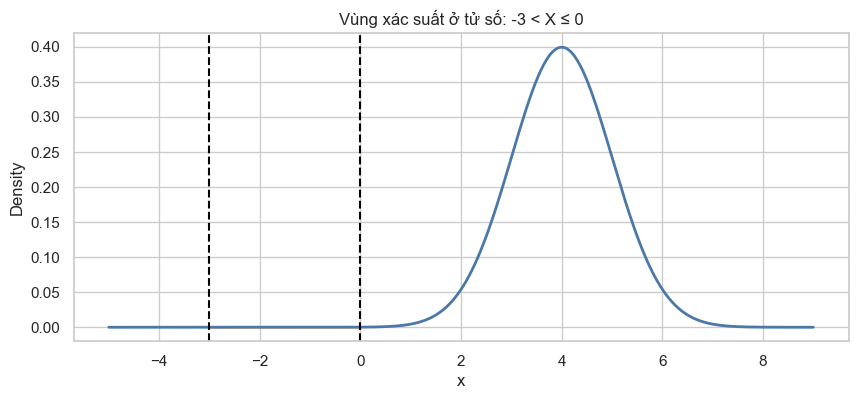

In [4]:
# Bài 3: sửa lỗi tham số trong đề và tính xác suất điều kiện bằng CDF của phân phối chuẩn.
mu = 4
sigma = abs(-1)
conditional_probability = (
    stats.norm.cdf(0, loc=mu, scale=sigma)
    - stats.norm.cdf(-3, loc=mu, scale=sigma)
) / (1 - stats.norm.cdf(-3, loc=mu, scale=sigma))

print(f"Using repaired sigma = {sigma:.0f}")
print(f"P(X <= 0 | X > -3) = {conditional_probability:.8f}")

x = np.linspace(-5, 9, 500)
y = stats.norm.pdf(x, loc=mu, scale=sigma)
plt.figure(figsize=(10, 4))
plt.plot(x, y, color="#4C78A8", linewidth=2)
plt.fill_between(x, 0, y, where=(x > -3) & (x <= 0), color="#F58518", alpha=0.5)
plt.axvline(-3, color="black", linestyle="--")
plt.axvline(0, color="black", linestyle="--")
plt.title("Vùng xác suất ở tử số: -3 < X ≤ 0")
plt.xlabel("x")
plt.ylabel("Density")
plt.show()


### Interpretation

Xác suất điều kiện này rất nhỏ, xấp xỉ $3.17 \times 10^{-5}$. Điều đó không có gì lạ vì phân phối chuẩn có trung bình bằng 4 và độ lệch chuẩn bằng 1, nên vùng $(-3, 0]$ nằm rất xa về phía trái của trung tâm phân phối. Bài này là lời nhắc quan trọng rằng kiểm tra tính hợp lệ của tham số luôn là một phần của tư duy mô hình hóa.


## 6. Bài 4 - Chiều cao sinh viên như một biến ngẫu nhiên liên tục

### Problem framing

Ta mô hình chiều cao sinh viên bằng phân phối chuẩn với trung bình 160 cm và độ lệch chuẩn 15 cm. Đây là một mô hình xấp xỉ cho quần thể sinh viên của lớp, còn dữ liệu mô phỏng 55 quan sát đóng vai trò như một mẫu ngẫu nhiên từ quần thể đó.

### Ý nghĩa của bài tập

Bài này giúp nối phân phối chuẩn từ công thức lý thuyết sang ý nghĩa thống kê thực nghiệm. Ta có một mô hình quần thể cho chiều cao, rồi xem mẫu ngẫu nhiên 55 quan sát như một cách nhìn cục bộ vào quần thể đó.

Điều quan trọng ở đây là sinh viên thấy được mối liên hệ giữa mô hình xác suất và dữ liệu mô phỏng. Một phân phối liên tục không chỉ dùng để tính xác suất, mà còn để sinh dữ liệu giả lập, so sánh trực quan và kiểm tra trực giác về biến thiên trong quần thể.


### Đề bài nhắc lại

**Bài 4.** Chiều cao sinh viên lớp KHDL16A được giả sử có phân phối chuẩn với kỳ vọng $160$ cm và độ lệch chuẩn $15$ cm.

- a) Sinh một mẫu dữ liệu kích thước $55$ và trực quan hóa.
- b) Tính xác suất một sinh viên cao hơn $170$ cm, và xác suất chiều cao nằm trong khoảng $165$ cm đến $172$ cm.
- c) Tìm $x$ sao cho xác suất chiều cao không vượt quá $x$ bằng $0.2024$.


### Công thức cốt lõi và cách đọc

Mô hình lý thuyết của bài là:

$$
X\sim N(160, 15^2).
$$

Do đó các xác suất cần tính đều có thể đưa về hàm phân phối chuẩn chuẩn hóa:

$$
P(X>170)=1-\Phi\left(\frac{170-160}{15}\right),
$$

$$
P(165\le X\le 172)=\Phi\left(\frac{172-160}{15}\right)-\Phi\left(\frac{165-160}{15}\right).
$$

Phần sinh mẫu kích thước 55 chỉ là một dữ liệu mô phỏng từ mô hình trên. Nó giúp ta nhìn trực quan một mẫu hữu hạn có thể dao động quanh phân phối chuẩn lý thuyết như thế nào.


P(X > 170) = 0.2525
P(165 < X < 172) = 0.1576


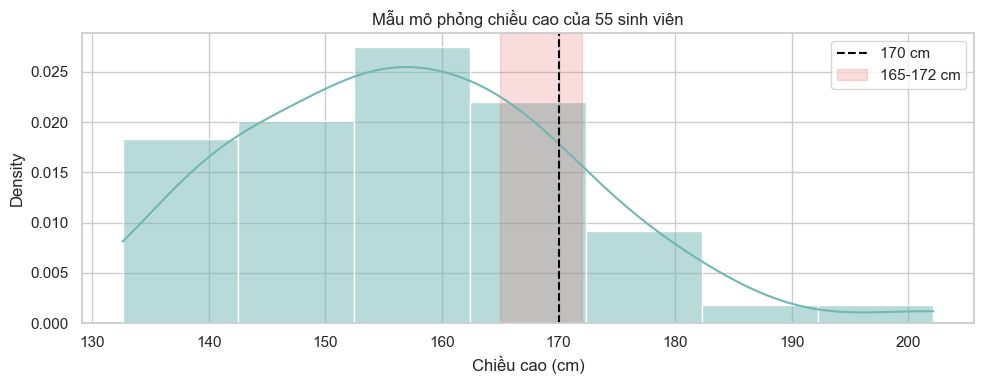

In [5]:
# Bài 4: mô phỏng dữ liệu chiều cao và đối chiếu sample giả lập với xác suất lý thuyết từ mô hình chuẩn.
height_mean = 160
height_sd = 15
sample_size = 55
height_sample = rng.normal(loc=height_mean, scale=height_sd, size=sample_size)
height_dist = stats.norm(loc=height_mean, scale=height_sd)

prob_above_170 = height_dist.sf(170)
prob_between_165_172 = height_dist.cdf(172) - height_dist.cdf(165)

print(f"P(X > 170) = {prob_above_170:.4f}")
print(f"P(165 < X < 172) = {prob_between_165_172:.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(height_sample, kde=True, stat="density", color="#72B7B2", ax=ax)
ax.axvline(170, color="black", linestyle="--", label="170 cm")
ax.axvspan(165, 172, color="#E45756", alpha=0.2, label="165-172 cm")
ax.set_title("Mẫu mô phỏng chiều cao của 55 sinh viên")
ax.set_xlabel("Chiều cao (cm)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()


### Interpretation and reflection

Theo mô hình chuẩn, xác suất chọn ngẫu nhiên một sinh viên cao hơn 170 cm vào khoảng 25.25%, còn xác suất chiều cao nằm giữa 165 cm và 172 cm vào khoảng 17.90%. Mô hình chuẩn thường hữu ích như một xấp xỉ đầu tiên, nhưng với dữ liệu thật ta vẫn nên kiểm tra lệch, đuôi dày hoặc sự khác biệt giữa nhóm nam và nữ trước khi kết luận mạnh.


## 7. Bài 5.1 - Kiểm tra và khai thác một mật độ liên tục

### Problem framing

Ta được cho một hàm ứng viên cho mật độ của biến ngẫu nhiên liên tục. Trước khi tính kỳ vọng hay phương sai, việc đầu tiên phải làm là chuẩn hóa để tổng xác suất bằng 1. Đây chính là bước kiểm tra xem hàm đó có thể đóng vai trò một phân phối hợp lệ hay không.

### Ý nghĩa của bài tập

Bài 5.1 chạm vào một nguyên tắc nền móng của mọi mô hình xác suất: trước khi nói đến kỳ vọng, phương sai hay posterior, ta phải chắc rằng đối tượng mình đang dùng thật sự là một mật độ hợp lệ. Nếu hàm không chuẩn hóa được hoặc vi phạm support, mọi suy luận phía sau đều sụp đổ.

Trong Bayesian analysis, bước này còn quan trọng hơn vì prior, likelihood và posterior đều có thể là các hàm liên tục. Bài tập buộc người học đặt câu hỏi về tính hợp lệ của mô hình trước khi hỏi về kết quả của mô hình.


### Đề bài nhắc lại

**Bài 5.1.** Cho biến ngẫu nhiên liên tục $X$ có mật độ
$$
f_X(x)=\begin{cases}
k(x^2-5x+4), & 1\le x\le 4,\\
0, & \text{khác.}
\end{cases}
$$
Hãy kiểm tra tính hợp lệ của mật độ, tìm hằng số chuẩn hóa, và khai thác các đặc trưng cơ bản của phân phối.


### Công thức cốt lõi và cách đọc

Trước khi tính bất kỳ đại lượng nào, ta phải chuẩn hóa hàm mật độ bằng điều kiện tổng xác suất bằng 1:

$$
1=\int_{1}^{4} k(x^2-5x+4)\,dx.
$$

Sau khi tìm được hằng số $$k$$, các đặc trưng cơ bản của phân phối được tính bởi:

$$
E[X]=\int_{1}^{4} x f_X(x)\,dx,
$$

$$
E[X^2]=\int_{1}^{4} x^2 f_X(x)\,dx,
\qquad
\mathrm{Var}(X)=E[X^2]-E[X]^2.
$$

Một chi tiết đáng học là biểu thức $$x^2-5x+4$$ âm trên khoảng $$(1,4)$$, nên để mật độ không âm thì hằng số chuẩn hóa $$k$$ phải âm. Đó là lý do bước kiểm tra dấu và miền xác định quan trọng không kém bước tích phân.


k = -0.222222
E[X] = 2.5000
Var(X) = 0.4500


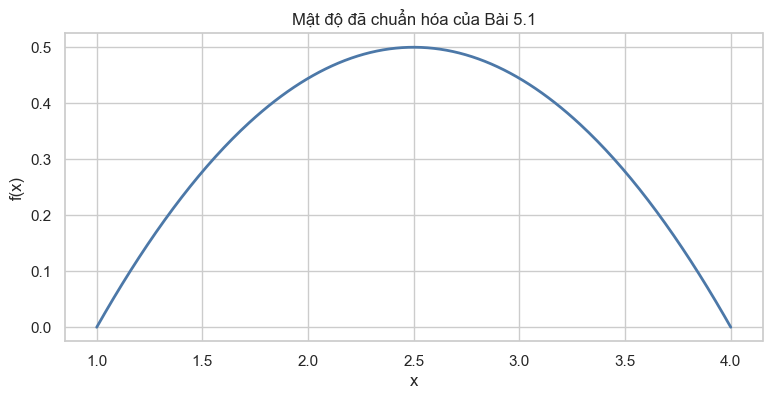

In [6]:
# Bài 5.1: trước hết chuẩn hóa hàm mật độ, rồi mới tính các đặc trưng như kỳ vọng và phương sai.
def pdf_51_raw(x):
    return x**2 - 5*x + 4

integral_raw, _ = quad(pdf_51_raw, 1, 4)
k_51 = 1 / integral_raw
pdf_51 = lambda x: k_51 * pdf_51_raw(x)

mean_51, _ = quad(lambda x: x * pdf_51(x), 1, 4)
second_moment_51, _ = quad(lambda x: x**2 * pdf_51(x), 1, 4)
var_51 = second_moment_51 - mean_51**2

print(f"k = {k_51:.6f}")
print(f"E[X] = {mean_51:.4f}")
print(f"Var(X) = {var_51:.4f}")

x_grid_51 = np.linspace(1, 4, 300)
plt.figure(figsize=(9, 4))
plt.plot(x_grid_51, [pdf_51(x) for x in x_grid_51], color="#4C78A8", linewidth=2)
plt.title("Mật độ đã chuẩn hóa của Bài 5.1")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()


### Interpretation

Ta thu được $k = -\frac{2}{9}$, nên mật độ chuẩn hóa là dương trên đoạn $[1,4]$ vì biểu thức $x^2 - 5x + 4$ âm trên khoảng này. Kỳ vọng bằng 2.5 cho thấy phân phối cân bằng quanh trung điểm của đoạn, còn phương sai khoảng 0.45 cho thấy khối lượng xác suất tập trung tương đối gần trung tâm.


## 8. Bài 5.2 - Một mật độ khác và các đặc trưng vị trí

Ở bài này ta lặp lại logic của Bài 5.1 nhưng thêm mode và median. Đây là cơ hội tốt để nhấn mạnh rằng mean, median và mode không nhất thiết giống nhau, dù trong trường hợp đối xứng chúng có thể trùng nhau.

### Ý nghĩa của bài tập

Bài 5.2 mở rộng Bài 5.1 bằng cách cho thấy một phân phối hợp lệ vẫn có thể được tóm tắt theo nhiều cách khác nhau. Mean, median và mode trả lời ba câu hỏi khác nhau về vị trí trung tâm, và chúng chỉ trùng nhau trong những trường hợp có cấu trúc thuận lợi.

Đây là nền tảng rất gần với quyết định Bayesian ở các lab sau. Khi người học hiểu vì sao các thước đo trung tâm có thể khác nhau, họ sẽ dễ chấp nhận hơn việc posterior mean, median hay MAP không nhất thiết phải trùng nhau.


### Đề bài nhắc lại

**Bài 5.2.** Cho biến ngẫu nhiên $X$ có mật độ
$$f(x)=kx(2-x),\quad 0\le x\le 2.$$

- 1) Thực hiện lại các thao tác tính toán như ở bài 5.1.
- 2) Tính thêm mode và median của phân phối này.


### Công thức cốt lõi và cách đọc

Bài này lặp lại quy trình chuẩn hóa nhưng thêm median và mode. Trước hết:

$$
1=\int_{0}^{2} kx(2-x)\,dx.
$$

Kỳ vọng và phương sai vẫn được tính bằng:

$$
E[X]=\int_{0}^{2} x f(x)\,dx,
\qquad
\mathrm{Var}(X)=E[X^2]-E[X]^2.
$$

Mode là điểm cực đại của mật độ, nên ta giải:

$$
\frac{d}{dx}\bigl[kx(2-x)\bigr]=0.
$$

Median $$m$$ là nghiệm của phương trình phân nửa khối lượng xác suất:

$$
\int_{0}^{m} f(x)\,dx=\frac{1}{2}.
$$

Vì mật độ này đối xứng quanh $$x=1$$, ba thước đo vị trí mean, median và mode đều gặp nhau tại trung tâm đó.


k = 0.7500
E[X] = 1.0000
Var(X) = 0.2000
Mode = 1.0000
Median = 1.0000


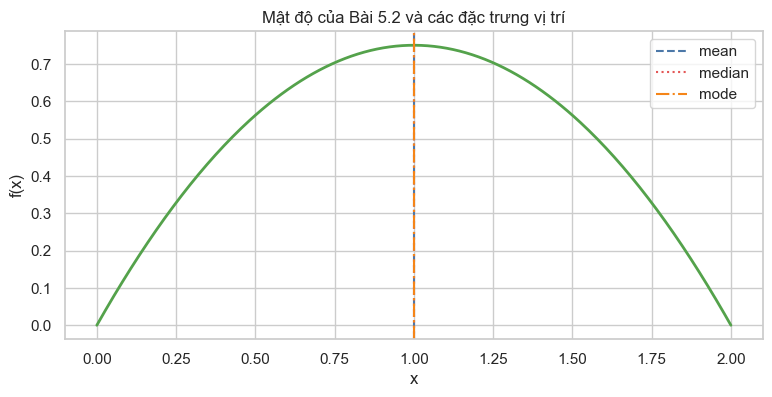

In [7]:
# Bài 5.2: lặp lại quy trình chuẩn hóa nhưng bổ sung median và mode để so sánh các thước đo vị trí.
def pdf_52_raw(x):
    return x * (2 - x)

integral_52, _ = quad(pdf_52_raw, 0, 2)
k_52 = 1 / integral_52
pdf_52 = lambda x: k_52 * pdf_52_raw(x)

mean_52, _ = quad(lambda x: x * pdf_52(x), 0, 2)
second_moment_52, _ = quad(lambda x: x**2 * pdf_52(x), 0, 2)
var_52 = second_moment_52 - mean_52**2
cdf_52 = lambda x: k_52 * (x**2 - x**3 / 3) if 0 <= x <= 2 else (0 if x < 0 else 1)
median_52 = brentq(lambda x: cdf_52(x) - 0.5, 0, 2)
mode_52 = 1.0

print(f"k = {k_52:.4f}")
print(f"E[X] = {mean_52:.4f}")
print(f"Var(X) = {var_52:.4f}")
print(f"Mode = {mode_52:.4f}")
print(f"Median = {median_52:.4f}")

x_grid_52 = np.linspace(0, 2, 300)
plt.figure(figsize=(9, 4))
plt.plot(x_grid_52, [pdf_52(x) for x in x_grid_52], color="#54A24B", linewidth=2)
plt.axvline(mean_52, color="#4C78A8", linestyle="--", label="mean")
plt.axvline(median_52, color="#E45756", linestyle=":", label="median")
plt.axvline(mode_52, color="#F58518", linestyle="-.", label="mode")
plt.title("Mật độ của Bài 5.2 và các đặc trưng vị trí")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.show()


### Interpretation

Kết quả cho thấy $k = \frac{3}{4}$, $E[X] = 1$, $\mathrm{Var}(X) = 0.2$, median bằng 1 và mode cũng bằng 1. Sự trùng nhau này đến từ tính đối xứng của mật độ quanh điểm 1. Trong các bài toán Bayesian, những mật độ đối xứng như vậy thường được dùng làm prior khi ta tin rằng giá trị trung tâm là hợp lý nhất nhưng vẫn muốn cho phép dao động hai phía.


## 9. Model criticism and reflection

Lab 3 cho thấy một điều quan trọng: không phải bài nào có công thức Bayes cũng tự động là “mô hình tốt”. Ở Bài 2, phân phối mũ chỉ hợp lý khi hazard gần như không đổi. Ở Bài 4, chuẩn chỉ là một xấp xỉ cho chiều cao thực tế. Ở Bài 5, nếu hàm mật độ không chuẩn hóa hoặc âm trên support thì toàn bộ mô hình xác suất sụp đổ ngay từ đầu.

Một điểm khác cũng đáng nhấn mạnh là nhiều quyết định mô hình hóa đều có lựa chọn thay thế hợp lý. Chẳng hạn ở Bài 1 ta dùng prior đều trên $k$, nhưng một prior tập trung quanh 5 cũng có thể bảo vệ được nếu có lý do thực nghiệm. Suy luận Bayes tốt luôn đi cùng việc nói rõ các lựa chọn này và hậu quả của chúng.


## 10. Conceptual interpretation questions

**Câu 1.** Ở Bài 1, vì sao posterior cuối cùng lại tập trung hoàn toàn vào $k=6$?  
**Trả lời ngắn:** vì sau khi bốc hết 10 viên, dữ liệu đã tiết lộ chính xác tổng số bi đỏ trong hộp; bất định ban đầu không còn nữa.

**Câu 2.** Ở Bài 2, xác suất 0.5507 nên được đọc như thế nào?  
**Trả lời ngắn:** dưới mô hình tuổi thọ mũ với kỳ vọng 6.25 năm, khoảng 55% linh kiện dự kiến sẽ hỏng trước khi hết 5 năm bảo hành.

**Câu 3.** Vì sao lỗi $\sigma = -1$ ở Bài 3 không thể bỏ qua?  
**Trả lời ngắn:** vì độ lệch chuẩn là tham số về độ phân tán nên luôn phải dương; kiểm tra tính hợp lệ của tham số là một phần của kiểm tra mô hình.

**Câu 4.** Ở Bài 5, bước chuẩn hóa mật độ liên tục có vai trò gì trong tư duy Bayes?  
**Trả lời ngắn:** nó đảm bảo hàm đang xét thật sự là một phân phối xác suất hợp lệ, từ đó mới có thể dùng làm prior, likelihood hay posterior.


## 11. Final takeaway

Điểm cốt lõi của lab này là bất định có thể được biểu diễn theo nhiều cách nhưng luôn phải bám vào câu chuyện sinh dữ liệu. Với hộp bi, bất định nằm ở số lượng bi đỏ chưa biết và được cập nhật sau mỗi lượt quan sát. Với tuổi thọ và chiều cao, bất định nằm ở các đại lượng liên tục nên xác suất gắn với khoảng giá trị. Với các bài về mật độ, bài học lớn nhất là một mô hình Bayesian chỉ đáng tin khi các thành phần xác suất của nó được định nghĩa hợp lệ và được diễn giải đúng bối cảnh.


## 12. Lecture references

Nếu muốn quay lại đúng phần lecture để tháo từng cụm bài trong Lab 3, nên đọc lại các lecture sau:

- [Bài 2.2: Likelihood - Câu chuyện về Dữ liệu và Mô hình](../../contents/vi/chapter02/_posts/2025-01-02-02_02_likelihood.md): **Bài 1**: đọc lại cách viết likelihood từ cơ chế bốc không hoàn lại để thấy vì sao mỗi lượt quan sát lại làm đổi xác suất của các giả thuyết về chiếc hộp.
- [Bài 2.3: Prior - Mã hóa Kiến thức Ban đầu](../../contents/vi/chapter02/_posts/2025-01-02-02_03_prior.md): **Bài 1**: đọc lại khi muốn hiểu prior đều và prior tập trung quanh $k=5$ đang mã hóa hai cách tin ban đầu khác nhau như thế nào.
- [Bài 2.4: Posterior - Cập nhật Niềm tin với Dữ liệu](../../contents/vi/chapter02/_posts/2025-01-02-02_04_posterior.md): **Bài 1**: đọc lại để theo dõi posterior sau từng lượt bốc, thay vì chỉ nhìn đáp án cuối cùng sau khi mở hết hộp.
- [Bài 0.2: Các Phân phối Xác suất - Mô tả Sự Biến thiên trong Dữ liệu](../../contents/vi/chapter00/_posts/2025-01-02-00_02_common_distributions.md): **Bài 2**, **Bài 3** và **Bài 4**: đọc lại đặc điểm của Exponential và Normal để hiểu mô hình đang giả định gì về tuổi thọ linh kiện và chiều cao sinh viên.
- [00-07: Hàm Mật độ Xác suất (PDF) - Chi tiết](../../contents/vi/chapter00/_posts/2025-01-02-00_07_probability_density_functions.md): **Bài 5.1** và **Bài 5.2**: đọc lại điều kiện một hàm là mật độ hợp lệ trước khi tính mean, median, mode hay bất kỳ đại lượng nào khác.
